# Modeling: peat condition -> fire

End-to-end scaffold for the modeling phase (see `modeling_roadmap.md`,
`decisions.md`). Flow:

1. Load the peat frame (80% histosol), restoration sites (treatment), covariates.
2. **Build the treated/control pixel-year panel** -- calendar-year dimension,
   per-year `treated`, and `years_after_treatment` event time.
   - **2b.** Thread the restoration year into `did.attach_cohort` and fit the
     staggered difference-in-differences (Callaway & Sant'Anna / Castro et al.).
3. `build_frame` -> tidy pixel-year table with a swappable fire response
   (the **levels / odds-ratio** route; consumes matched `units` from Stage 5-7).
4. `fit_logit_clustered` -> `odds_ratios`.

Matching adjusts on every **continuous** covariate on disk: elevation, histosol %,
the GHCN **climate normals** (precip/tmax, interpolated onto the grid in step 1b),
and the **SSURGO soil** layers. Categorical layers (drainage class, land cover) are
exact-match keys. Diagnostic plots at each step let you inspect the data as it flows.

In [1]:
# standard library
from pathlib import Path

# third-party
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# local (peatfire)
from peatfire import (
    data_path,
    build_common_grid,
    to_common_grid,
    rasterize_polygons_to_grid,
    load_standardized,
    set_fire_style,
)
from peatfire.modeling import (
    load_completed_restoration_sites_in_analysis_crs,
    available_covariates,
    list_covariates,
    covariate_on_grid,
    build_frame,
    fit_logit_clustered,
    odds_ratios,
    pixelate,
    climate,
    build_soil_rasters,
    inspect_soil_columns,
    plot_covariate_maps,
    plot_covariate_space,
    plot_covariate_pairs,
    plot_matched_pairs_covariate,
    plot_matched_pairs_geographic,
)
from peatfire.modeling import did
from peatfire.modeling.matching import (
    get_treated_and_control_pixels,
    attach_covariates,
    match_controls,
    balance_table,
    plot_balance,
    assemble_units,
    check_matches,
    check_balance,
)

set_fire_style()

# Every figure in this notebook is written here.
FIG_DIR = Path(data_path()).parents[0] / "outputs" / "figures" / "modeling"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("covariates on disk:", available_covariates())
print("figures ->", FIG_DIR)

covariates on disk: ['elevation', 'histosol_pct']
figures -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:248: UserWarning: precip_normal: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/climate does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:248: UserWarning: tmax_normal: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/climate does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:248: UserWarning: tmin_normal: directory /Users/jinjiang-macair/Librar

## 1. Load treatment + peat frame

In [2]:
# Restoration polygons = the TREATMENT (reprojected to EPSG:5070; metres).
restoration_yr_col = 'End_Yr'
peat_restoration = load_completed_restoration_sites_in_analysis_crs(restoration_yr_col=restoration_yr_col) # drops rows with 0 for the restoration_yr_col and reprojects to EPSG:5070


In [3]:
# 80% peat extent as the sample frame.
aoi_nc_peat_80_histosol = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_80_histosol_aoi.gpkg"))

## 1b. Climate covariates from GHCN stations, then map every layer

The climate source (`src/get_climate&soil_data.R`) gives GHCN **station points**,
not a raster. Two products come off the same station records:

- `climate.build_climate_normals` collapses each station's daily record to a
  long-run **normal** (annual precip total / mean tmax-tmin over the baseline) and
  IDW-interpolates it onto the grid; `write_climate_normals` saves them under
  `data/processed/climate/` as the **static** covariates `precip_normal`,
  `tmax_normal`, `tmin_normal`. A normal is the right thing to **match** on --
  climate is a stable site characteristic.
- `climate.build_annual_climate` interpolates each **single year's** value onto
  the grid; `write_annual_climate` saves them under
  `data/processed/climate/annual/` (`precip_<year>_nc.tif` ...) as the
  **temporal** covariates `precip`, `tmax`, `tmin`. This year-specific weather
  belongs in the DiD / outcome stage (a `treated:precip` dry-year interaction) and
  is joined per `(x, y, year)` by `build_frame` / `attach_covariates`.

Then `plot_covariate_maps` draws every static covariate over the peat AOI. A
visually **flat** panel (histosol %, pinned ~90 across the 80% frame) is a
covariate with no spatial signal to match on -- the reason the elevation-only
match was degenerate, and the motivation for adding climate + soil.

wrote climate normals: {'precip_normal': 'precip_normal_nc.tif', 'tmax_normal': 'tmax_normal_nc.tif', 'tmin_normal': 'tmin_normal_nc.tif'}


/Users/jinjiang-macair/anaconda3/envs/peat_fire_stanback/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'nc_soil_ssurgo.gpkg': 'geometry' (default), 'chaashto', 'chconsistence', 'chdesgnsuffix', 'chfrags', 'chorizon', 'chstruct', 'chstructgrp', 'chtexture', 'chtexturegrp', 'chtexturemod', 'chunified', 'cocropyld', 'codiagfeatures', 'coecoclass', 'coeplants', 'coerosionacc', 'coforprod', 'cogeomordesc', 'cohydriccriteria', 'cointerp', 'comonth', 'component', 'copm', 'copmgrp', 'corestrictions', 'cosoilmoist', 'cosurfmorphgc', 'cosurfmorphhpp', 'cosurfmorphmr', 'cosurfmorphss', 'cotaxfmmin', 'cotaxmoistcl', 'cotext', 'cotreestomng', 'cotxfmother', 'distinterpmd', 'distlegendmd', 'distmd', 'laoverlap', 'legend', 'mapunit', 'mdstatdomdet', 'mdstatdommas', 'mdstatidxdet', 'mdstatidxmas', 'mdstatrshipdet', 'mdstatrshipmas', 'mdstattabcols', 'mdstattabs', 'muaggatt', 'muaoverlap', 'sacatalog', 'sainterp', 'sdvalgorithm', 'sdvattribute', 'sdvfo

nc_soil_ssurgo.gpkg: 341,835 polygons, 4 polygon columns
    column   dtype  n_unique  n_null                           sample
AREASYMBOL     str        40       0     [NC013, NC015, NC017, NC019]
SPATIALVER float64        10       0           [4.0, 8.0, 14.0, 11.0]
     MUSYM     str       585       0               [StA, Le, Sb, TaB]
     MUKEY     str      1809       0 [111607, 111581, 111605, 111611]
soil build skipped: Failed to open dataset (flags=68): /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/interim/soil/ssurgo/nc_soil_ssurgo.gpkg
covariates on disk now: ['elevation', 'histosol_pct', 'precip_normal', 'tmax_normal', 'tmin_normal']


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:248: UserWarning: soil_organic_matter: no file matches ssurgo_organic_matter*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:248: UserWarning: soil_awc: no file matches ssurgo_awc*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/soil/ssurgo -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:248: UserWarning: soil

saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/covariate_maps.png


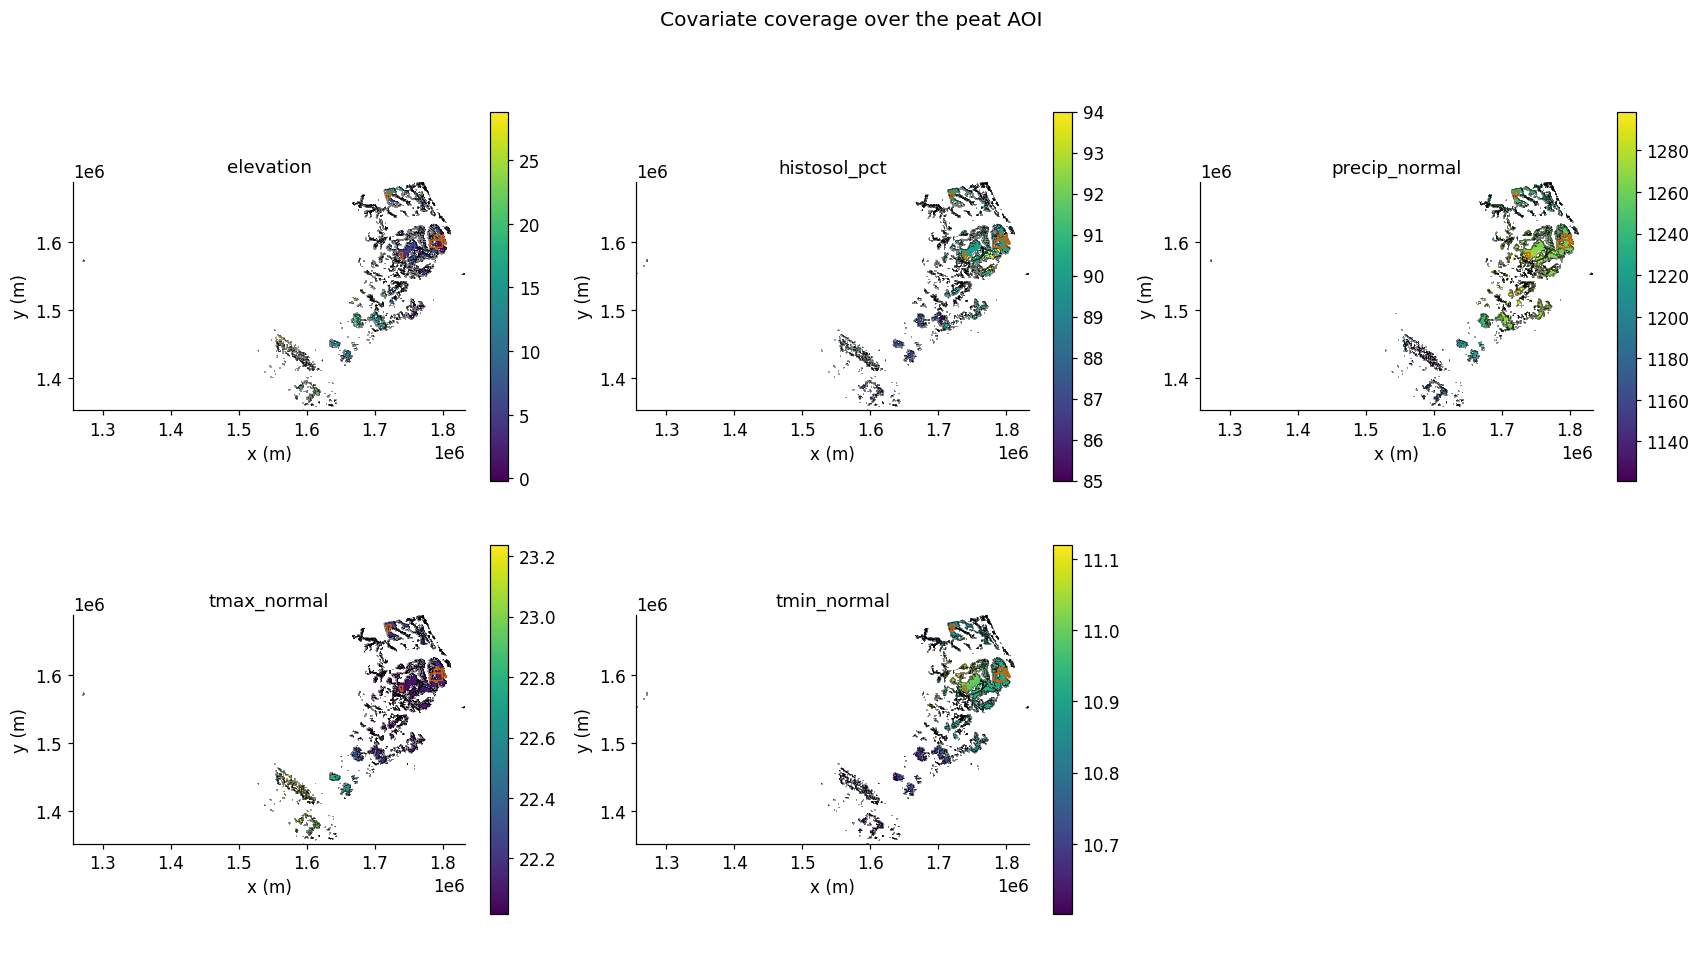

In [4]:
RES_M = 300   # analysis resolution (FireCCIS311 native ~300 m); reused below
YEARS = range(2019, 2025)   # panel / fire-product coverage; per-year climate built for these

# --- Climate from the GHCN .Rds long tables (one per element) ------------------
# load_ghcn_stations reads .Rds directly (via pyreadr): each long table carries
# one value column (PRCP / TMAX / TMIN) plus station lon/lat and a YEAR. The same
# loaded station frames feed two products:
#   * build_climate_normals -> a long-run NORMAL per pixel (STATIC): the stable
#     site climate the geographic MATCH keys off (precip_normal / tmax_normal /
#     tmin_normal in processed/climate/).
#   * build_annual_climate  -> one grid per (element, YEAR) (TEMPORAL): the
#     year-specific weather the OUTCOME / DiD stage uses (a treated:precip dry-year
#     interaction), written to processed/climate/annual/ as precip_<year>_nc.tif ...
#     and registered as the temporal covariates precip / tmax / tmin.
ghcn = data_path("interim", "climate", "ghcn")
try:
    prcp = climate.load_ghcn_stations(ghcn / "nc_prcp_long.Rds")
    tmax = climate.load_ghcn_stations(ghcn / "nc_tmax_long.Rds")
    tmin = climate.load_ghcn_stations(ghcn / "nc_tmin_long.Rds")

    # Static normals for matching (mean over the 1991-2020 baseline).
    normals = climate.build_climate_normals(
        {"precip_normal": prcp, "tmax_normal": tmax, "tmin_normal": tmin},
        aoi_nc_peat_80_histosol,
        res_m=RES_M, baseline=(1991, 2020),   # None = use every year present
    )
    written = climate.write_climate_normals(normals)
    print("wrote climate normals:", {k: p.name for k, p in written.items()})

    # Per-year weather for the outcome / DiD stage.
    annual = climate.build_annual_climate(
        {"precip": prcp, "tmax": tmax, "tmin": tmin},
        aoi_nc_peat_80_histosol,
        years=YEARS, res_m=RES_M,
    )
    written_annual = climate.write_annual_climate(annual)
    print(f"wrote {len(written_annual)} per-year climate rasters: "
          f"{sorted({e for e, _ in written_annual})} x "
          f"{sorted({y for _, y in written_annual})}")
except (FileNotFoundError, ValueError) as e:
    print("climate build skipped:", e)

# --- Soil covariates from the SSURGO GeoPackage (polygons, not a raster) -------
# Inspect the attribute columns first, then rasterise the ones you want onto the
# grid. The defaults (om_r, awc_r, drainagecl) are standard gSSURGO names; if your
# export differs, the printed columns tell you what to pass as `attributes=`.
soil_gpkg = data_path("interim", "soil", "ssurgo", "nc_soil_ssurgo.gpkg")
try:
    inspect_soil_columns(soil_gpkg)                    # <- read the columns here
    build_soil_rasters(soil_gpkg, aoi_nc_peat_80_histosol, res_m=RES_M)

except Exception as e:
    print("soil build skipped:", e)

print("covariates on disk now:", available_covariates())

# Map every covariate on disk (elevation, histosol %, climate normals, soil). A
# visually flat panel = a covariate with no spatial signal to match on.
fig = plot_covariate_maps(
    aoi_nc_peat_80_histosol,
    names=available_covariates(),
    res_m=RES_M,
    treated=peat_restoration,          # outline restoration sites for context
)
fig.savefig(FIG_DIR / "covariate_maps.png", bbox_inches="tight")
print("saved", FIG_DIR / "covariate_maps.png")

In [5]:
inspect_soil_columns()

/Users/jinjiang-macair/anaconda3/envs/peat_fire_stanback/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'nc_soil_ssurgo.gpkg': 'geometry' (default), 'chaashto', 'chconsistence', 'chdesgnsuffix', 'chfrags', 'chorizon', 'chstruct', 'chstructgrp', 'chtexture', 'chtexturegrp', 'chtexturemod', 'chunified', 'cocropyld', 'codiagfeatures', 'coecoclass', 'coeplants', 'coerosionacc', 'coforprod', 'cogeomordesc', 'cohydriccriteria', 'cointerp', 'comonth', 'component', 'copm', 'copmgrp', 'corestrictions', 'cosoilmoist', 'cosurfmorphgc', 'cosurfmorphhpp', 'cosurfmorphmr', 'cosurfmorphss', 'cotaxfmmin', 'cotaxmoistcl', 'cotext', 'cotreestomng', 'cotxfmother', 'distinterpmd', 'distlegendmd', 'distmd', 'laoverlap', 'legend', 'mapunit', 'mdstatdomdet', 'mdstatdommas', 'mdstatidxdet', 'mdstatidxmas', 'mdstatrshipdet', 'mdstatrshipmas', 'mdstattabcols', 'mdstattabs', 'muaggatt', 'muaoverlap', 'sacatalog', 'sainterp', 'sdvalgorithm', 'sdvattribute', 'sdvfo

nc_soil_ssurgo.gpkg: 341,835 polygons, 4 attribute columns
    column   dtype  n_unique  n_null                           sample
AREASYMBOL     str        40       0     [NC013, NC015, NC017, NC019]
SPATIALVER float64        10       0           [4.0, 8.0, 14.0, 11.0]
     MUSYM     str       585       0               [StA, Le, Sb, TaB]
     MUKEY     str      1809       0 [111607, 111581, 111605, 111611]


,column,dtype,n_unique,n_null,sample
0,AREASYMBOL,str,40,0,"[NC013, NC015, NC017, NC019]"
1,SPATIALVER,float64,10,0,"[4.0, 8.0, 14.0, 11.0]"
2,MUSYM,str,585,0,"[StA, Le, Sb, TaB]"
3,MUKEY,str,1809,0,"[111607, 111581, 111605, 111611]"


## 2. Build matched controls

**a. Clip-to-drop** the restoration sites (plus a buffer) from the peat frame to
get the control *candidate* pool. `how="difference"` is the inverse of clip:

```python
BUFFER_M = 1000  # exclusion halo around restoration sites, in metres
exclusion = gpd.GeoDataFrame(geometry=[restoration.buffer(BUFFER_M).union_all()],
                             crs=restoration.crs)
candidates = gpd.overlay(aoi_nc_peat_80_histosol, exclusion, how="difference")
```

**b. Candidate pixels + nearest site.** Turn candidate peat into pixel points
(e.g. centroids of the grid cells over `candidates`), then attach each one's
nearest restoration site and distance in one call:

```python
cand_pts = gpd.sjoin_nearest(candidate_points, restoration,
                             how="left", distance_col="dist_m")
```

**c. Sample covariates** at treated and candidate pixels (reuse the grid warp):
`covariate_on_grid('elevation', grid, aoi)` and `('histosol_pct', ...)`, then
read values at the pixel locations. Assemble a table with a `treatment` 0/1
column + `elevation`, `histosol_pct`.

**d. Match** treated<->control on those covariates. Two options:
- literal nearest-neighbour on z-scored covariates: `sklearn.neighbors.NearestNeighbors`
- propensity score: `pymatch.Matcher(...).fit_scores(); .match(); .matched_data`
  (matches on P(treatment), not raw covariates -- know the difference).

Output of this section: a `units` GeoDataFrame with **`treated`** (1/0),
**`site_id`** (the matched stratum), and **`unit_id`** columns. That is all
`build_frame` needs.

In [3]:
spillover_m = 1000
res_m = RES_M                      # 300 m, defined in step 1b
years = range(2019, 2025)          # FireCCIS311 coverage

# Match on every CONTINUOUS covariate on disk: elevation + histosol %, plus the
# climate normals and SSURGO soil layers built/registered above. This is what
# breaks the 'match on elevation alone' degeneracy -- histosol % is ~constant on
# the 80% frame, so without climate/soil the whitened distance had only elevation
# to work with. Categorical layers (drainage class, land cover) become exact-match
# keys in match_controls, not continuous axes here.
_on_disk = set(available_covariates())
covariates = [c for c in list_covariates('continuous') if c in _on_disk]
if not covariates:                 # safety net if nothing resolved
    covariates = ['histosol_pct', 'elevation']
# Categorical soil/land-cover layers become EXACT-match keys (matched within
# class), not continuous distance axes.
categorical = [c for c in list_covariates('categorical') if c in _on_disk]
print('matching on continuous covariates:', covariates)
print('exact-match (categorical) keys:', categorical)

# Pixel-YEAR panel (not a single flattened set): every candidate pixel is
# repeated once per calendar year, with
#   - `treated`                  1 once the pixel's site has been restored, else 0
#   - `<restoration_yr_col>`      the site's End_Yr (NaN for control-pool pixels)
#   - `years_after_restoration`  = year - End_Yr  (0 = restoration year,
#                                  matching the notebook's event_year convention)
# Control pixels appear in every year with treated=0. Pre-restoration site
# pixels are kept as *not-yet-treated* controls for the staggered DiD below
# (pass drop_pretreatment=True for the simpler restored-by-year-Y cross-section).
pixels = get_treated_and_control_pixels(
    aoi_nc_peat_80_histosol,
    peat_restoration,
    years=years,
    spillover_m=spillover_m,
    res_m=res_m,
    treated_col_name="treated",
    restoration_yr_col=restoration_yr_col,   # 'End_Yr', kept under this name
    site_col="Proj_Name",
)

# Static covariates are sampled once per pixel and broadcast across the years.
pixels_with_covariates = attach_covariates(pixels, covariates, aoi_nc_peat_80_histosol, res_m)

print(pixels_with_covariates.shape)
print("treated pixel-years by calendar year:")
print(pixels_with_covariates.groupby("year")["treated"].sum())
pixels_with_covariates.head()

### Inspect treated vs control in covariate space

Before matching, look at the two groups in covariate space. A **flat axis** is a
covariate with no spread (nothing to match on there); with climate + soil added,
treated and control should now separate on more than just elevation. The scatter
matrix shows every covariate axis at once.

In [ ]:
fig = plot_covariate_space(
    pixels_with_covariates, "elevation", "histosol_pct",
    restoration_yr_col=restoration_yr_col,
)
fig.savefig(FIG_DIR / "covariate_space_elev_histosol.png", bbox_inches="tight")

if len(covariates) >= 2:
    fig = plot_covariate_pairs(
        pixels_with_covariates, covariates, restoration_yr_col=restoration_yr_col,
    )
    fig.savefig(FIG_DIR / "covariate_pairs.png", bbox_inches="tight")
print("saved covariate-space diagnostics ->", FIG_DIR)

## 2b. Event-time panel → staggered DiD

The pixel-year panel above already carries what the staggered
difference-in-differences in `peatfire.modeling.did` needs: a per-pixel
`treated` that switches on at each site's `restoration_year`, and that
restoration year itself (the Callaway–Sant'Anna **cohort** `g`). Below we
attach the fire response per year, give every pixel a stable `unit_id`, thread
`restoration_year` into `did.attach_cohort`, and fit the group-time ATT.

This is the design that identifies off the *change* in burning after each
site's restoration relative to not-yet/never-restored controls, so every
time-invariant confounder differences out. The `build_frame` →
`fit_logit_clustered` route in §3–4 is the **levels / odds-ratio** alternative,
which consumes matched `units` polygons from Stage 5–7 rather than this panel.

In [4]:
# --- 1. fire response per (pixel, year), sampled from the swappable product ---
# Mirrors build_frame's per-year response step, but samples at pixel points
# instead of rasterizing polygons. Needs the fire product on disk.
product = "FireCCIS311"
grid = build_common_grid(aoi_nc_peat_80_histosol, res_m=res_m)

panel = pixels_with_covariates.copy()
panel["burned"] = np.nan
for year, idx in panel.groupby("year").groups.items():
    resp = load_standardized(product, int(year), aoi_nc_peat_80_histosol)
    if resp is None:                       # product missing this year -> leave NaN
        continue
    burned = to_common_grid(resp.astype("float32"), grid, how="max")
    sub = panel.loc[idx]
    xi = xr.DataArray(sub["x"].values, dims="point")
    yi = xr.DataArray(sub["y"].values, dims="point")
    panel.loc[idx, "burned"] = burned.sel(x=xi, y=yi, method="nearest").values

# --- 2. one stable entity id per distinct pixel (the DiD panel's entity) ---
panel["unit_id"] = panel.groupby(["x", "y"]).ngroup()

# --- 3. thread the restoration year -> CS cohort `g` (0 = never-treated controls) ---
# cohort_by maps each site to its first-treatment (restoration) year; control-pool
# pixels have no Proj_Name and fall through to g=0 (never-treated).
cohort_by = (
    panel.dropna(subset=[restoration_yr_col])
    .groupby("Proj_Name")[restoration_yr_col]
    .first()
)
panel = did.attach_cohort(panel, cohort_by=cohort_by, key="Proj_Name", treated_col="treated")

print("cohorts g:", sorted(panel["g"].unique()))
print("burned pixel-years with coverage:", int(panel["burned"].notna().sum()))
panel.head()

In [ ]:
# Reshape to the balanced (unit, year) panel and fit the doubly-robust
# group-time ATT (Callaway & Sant'Anna 2021). Needs `pip install differences`
# and a `burned` column with coverage, so we drop the year-loop's NaNs first.
# Wrapped so a missing optional backend / fire coverage doesn't abort the rest
# of the notebook (the levels / odds-ratio route in §3-4 is self-contained).
_cont = set(list_covariates('continuous'))
covs = [c for c in panel.columns if c in _cont]

event_study = None
try:
    cs_panel = did.build_panel(
        panel.dropna(subset=["burned"]),
        entity="unit_id",
        time="year",
        response="burned",
        covariates=covs,
    )

    att = did.estimate_att(cs_panel, response="burned", covariates=covs, cluster="unit_id")

    overall = did.aggregate_att(att, kind="simple")   # Castro's headline ATT
    event_study = did.aggregate_att(att, kind="event")  # pre-trends check + dynamics
    print("overall ATT:", overall)

    # Save the event-study path (pre-treatment points are the parallel-trends check).
    try:
        ax = att.plot("event")
        fig = ax.get_figure() if hasattr(ax, "get_figure") else plt.gcf()
        fig.savefig(FIG_DIR / "did_event_study.png", bbox_inches="tight")
        print("saved", FIG_DIR / "did_event_study.png")
    except Exception as e:  # backend plotter API differs / not available
        print("event-study plot skipped:", e)
except Exception as e:
    print("staggered DiD skipped (needs `differences` backend + fire coverage):", e)

event_study

In [6]:
# --- 1. fire response per (pixel, year), sampled from the swappable product ---
# Mirrors build_frame's per-year response step, but samples at pixel points
# instead of rasterizing polygons. Needs the fire product on disk.
product = "FireCCIS311"
grid = build_common_grid(aoi_nc_peat_80_histosol, res_m=res_m)

panel = pixels_with_covariates.copy()
panel["burned"] = np.nan
for year, idx in panel.groupby("year").groups.items():
    resp = load_standardized(product, int(year), aoi_nc_peat_80_histosol)
    if resp is None:                       # product missing this year -> leave NaN
        continue
    burned = to_common_grid(resp.astype("float32"), grid, how="max")
    sub = panel.loc[idx]
    xi = xr.DataArray(sub["x"].values, dims="point")
    yi = xr.DataArray(sub["y"].values, dims="point")
    panel.loc[idx, "burned"] = burned.sel(x=xi, y=yi, method="nearest").values

# --- 2. one stable entity id per distinct pixel (the DiD panel's entity) ---
panel["unit_id"] = panel.groupby(["x", "y"]).ngroup()

# --- 3. thread the restoration year -> CS cohort `g` (0 = never-treated controls) ---
# cohort_by maps each site to its first-treatment (restoration) year; control-pool
# pixels have no Proj_Name and fall through to g=0 (never-treated).
cohort_by = (
    panel.dropna(subset=[restoration_yr_col])
    .groupby("Proj_Name")[restoration_yr_col]
    .first()
)
panel = did.attach_cohort(panel, cohort_by=cohort_by, key="Proj_Name", treated_col="treated")

print("cohorts g:", sorted(panel["g"].unique()))
print("burned pixel-years with coverage:", int(panel["burned"].notna().sum()))
panel.head()

,x,y,geometry,End_Yr,Proj_Name,year,years_after_restoration,treated,histosol_pct,elevation,burned,unit_id,g
0,1.795060e+06,1.600476e+06,POINT (1795060.262 1600475.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,90.0,1.469855,0.0,53533,2019
1,1.792360e+06,1.598976e+06,POINT (1792360.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,90.0,3.633824,0.0,52560,2019
2,1.792660e+06,1.598976e+06,POINT (1792660.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,90.0,4.391799,0.0,52664,2019
3,1.792960e+06,1.598976e+06,POINT (1792960.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,90.0,3.524289,0.0,52766,2019
4,1.793260e+06,1.598976e+06,POINT (1793260.262 1598975.871),2019.0,Dare Bombing Range WMP,2019,0.0,1,90.0,2.983579,0.0,52876,2019


In [5]:
# Reshape to the balanced (unit, year) panel and fit the doubly-robust
# group-time ATT (Callaway & Sant'Anna 2021). Needs `pip install differences`
# and a `burned` column with coverage, so we drop the year-loop's NaNs first.
# Wrapped so a missing optional backend / fire coverage doesn't abort the rest
# of the notebook (the levels / odds-ratio route in §3-4 is self-contained).
covs = [c for c in ("elevation", "histosol_pct") if c in panel.columns]

event_study = None
try:
    cs_panel = did.build_panel(
        panel.dropna(subset=["burned"]),
        entity="unit_id",
        time="year",
        response="burned",
        covariates=covs,
    )

    att = did.estimate_att(cs_panel, response="burned", covariates=covs, cluster="unit_id")

    overall = did.aggregate_att(att, kind="simple")   # Castro's headline ATT
    event_study = did.aggregate_att(att, kind="event")  # pre-trends check + dynamics
    print("overall ATT:", overall)

    # Save the event-study path (pre-treatment points are the parallel-trends check).
    try:
        ax = att.plot("event")
        fig = ax.get_figure() if hasattr(ax, "get_figure") else plt.gcf()
        fig.savefig(FIG_DIR / "did_event_study.png", bbox_inches="tight")
        print("saved", FIG_DIR / "did_event_study.png")
    except Exception as e:  # backend plotter API differs / not available
        print("event-study plot skipped:", e)
except Exception as e:
    print("staggered DiD skipped (needs `differences` backend + fire coverage):", e)

event_study

staggered DiD skipped (needs `differences` backend + fire coverage): No module named 'differences'


### Match controls + balance (Stage 5-7) → `units`

This is the causal-design heart: pair every treated (restoration) pixel with the
nearest control pixel on the covariates, then *prove it worked*.

1. **`match_controls`** — whiten the covariates (so plain Euclidean distance =
   Mahalanobis) and nearest-neighbour match each treated pixel to a control
   within a caliper. Exact-match categoricals (land cover) once they download.
2. **`balance_table` + `plot_balance`** — the standardized mean difference (SMD)
   per covariate, *before* vs *after* matching. Before, the groups are offset;
   after, `|SMD|` should collapse below 0.1. That overlap is what later lets us
   attribute a fire difference to restoration rather than to geography. The love
   plot is saved to `outputs/figures/modeling/balance_love.png`.
3. **`assemble_units`** — shape the matched pixels into the `units` GeoDataFrame
   (`unit_id`, `site_id`, `treated`, `geometry`) that `build_frame` consumes in §3.

[match] 3550 treated matched to 3550 controls (k=1, caliper=1.0, replace=False); dropped 0 treated pixels with no control in caliper
[Stage 5 OK] 3,550 treated matched to 3,550 controls; max distance 0.287 <= caliper 1.
[Stage 6 OK] balance improved; post-match max |SMD| = 0.000.
              smd_before  smd_after
histosol_pct    0.592022   0.000040
elevation      -0.412614  -0.000021
site clusters (effective N): 5
saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/balance_love.png
units by treatment:
 treated
1    3550
0    3550
Name: count, dtype: int64


,unit_id,site_id,treated,geometry,x,y,histosol_pct,elevation,End_Yr,pair_id,match_distance
0,0,Dare Bombing Range WMP,1,POINT (1795060.262 1600475.871),1.795060e+06,1.600476e+06,90.0,1.469855,2019.0,0,0.000000
1,1,Dare Bombing Range WMP,0,POINT (1765060.262 1589675.871),1.765060e+06,1.589676e+06,90.0,1.469419,NaN,0,0.000062
2,2,Dare Bombing Range WMP,1,POINT (1792360.262 1598975.871),1.792360e+06,1.598976e+06,90.0,3.633824,2019.0,1,0.000000
3,3,Dare Bombing Range WMP,0,POINT (1720960.262 1661675.871),1.720960e+06,1.661676e+06,90.0,3.634259,NaN,1,0.000062
4,4,Dare Bombing Range WMP,1,POINT (1792660.262 1598975.871),1.792660e+06,1.598976e+06,90.0,4.391799,2019.0,2,0.000000


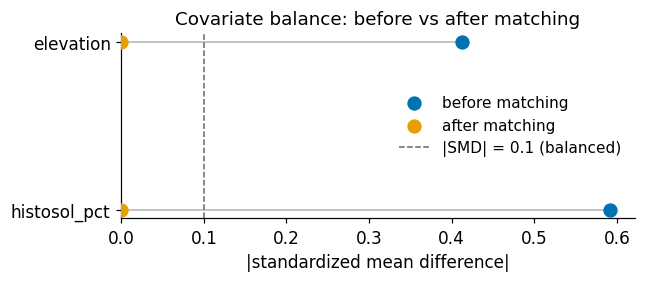

In [6]:
caliper = 1.0   # max match distance, in whitened (Mahalanobis SD) units
k = 1           # 1:1 matching

# --- Stage 6a: balance BEFORE matching -------------------------------------
# On the unmatched panel, balance_table collapses to unique pixels and splits by
# restoration-site membership (treated) vs the candidate pool (control).
before = balance_table(pixels_with_covariates, continuous=covariates,
                       restoration_yr_col=restoration_yr_col)

# --- Stage 5: nearest-neighbour match on the (whitened) covariates ---------
# No categorical layer on disk yet; add categorical=['land_cover'] to exact-match
# once it downloads. replace=False -> each control used at most once. site_id in
# the output is the restoration SITE (Proj_Name): a control inherits its matched
# treated pixel's site, so SEs later cluster on the handful of sites, not pixels.
matched = match_controls(
    pixels_with_covariates,
    continuous=covariates,
    categorical=(),
    caliper=caliper,
    k=k,
    replace=False,
    restoration_yr_col=restoration_yr_col,   # 'End_Yr'
    site_col="Proj_Name",
)

# --- Stage 6b: balance AFTER matching + the checks -------------------------
after = balance_table(matched, continuous=covariates)
check_matches(matched, caliper=caliper)   # every control within the caliper
check_balance(before, after)              # |SMD| shrank for every covariate

balance = before.join(after, lsuffix="_before", rsuffix="_after")
print(balance)
print("site clusters (effective N):", matched["site_id"].nunique())

# --- Stage 6c: the love plot (the figure that justifies the design) --------
ax = plot_balance(before, after)
ax.get_figure().savefig(FIG_DIR / "balance_love.png", bbox_inches="tight")
print("saved", FIG_DIR / "balance_love.png")

# --- Stage 7: package the matched pixels into `units` for build_frame ------
units = assemble_units(matched)
print("units by treatment:\n", units["treated"].value_counts())
units.head()

## 3. Build the tidy pixel-year frame

In [7]:
# Consumes the matched `units` from Stage 7. Response is swappable via `product=`.
# site_id_col='site_id' -> the restoration SITE assemble_units carries through;
# that is what fit_logit_clustered clusters the standard errors on (effective N =
# number of restoration sites, not pixels).
frame = build_frame(
    units,
    product="FireCCIS311",   # swap for a severity product to model severity
    years=range(2019, 2025),
    covariate_names=None,    # default = every covariate on disk (elev, histosol)
    site_id_col='site_id',
)
print(frame.shape)
print("burn rate by treatment:")
print(frame.groupby("treated")["burned"].mean())
frame.head()

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:184: UserWarning: land_cover: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/land_cover/LF2024_EVT_NC does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:184: UserWarning: drainage: no file matches hand_*_nc.tif in /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/drainage/hand -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]
/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:184: UserWarning: management: directory /User

(42582, 9)
burn rate by treatment:
treated
0.0    0.003430
1.0    0.034366
Name: burned, dtype: float32


unit_id  site_id  treated             y             x  elevation  \
0   6283.0      3.0      0.0  1.679226e+06  1.727410e+06  14.631072   
1   1393.0      2.0      0.0  1.678926e+06  1.727110e+06  14.463080   
2    235.0      2.0      0.0  1.678926e+06  1.732510e+06   6.789939   
3   6871.0      3.0      0.0  1.678626e+06  1.725310e+06  13.839990   
4   6353.0      3.0      0.0  1.678626e+06  1.725610e+06  15.425350   

   histosol_pct  year  burned  
0          90.0  2019     0.0  
1          90.0  2019     0.0  
2          90.0  2019     0.0  
3          90.0  2019     0.0  
4          90.0  2019     0.0

### Match controls + balance (Stage 5-7) → `units`

This is the causal-design heart: pair every treated (restoration) pixel with the
nearest control pixel on the covariates, then *prove it worked*.

1. **`match_controls`** — whiten the covariates (so plain Euclidean distance =
   Mahalanobis) and nearest-neighbour match each treated pixel to a control
   within a caliper. Exact-match categoricals (land cover) once they download.
2. **`balance_table` + `plot_balance`** — the standardized mean difference (SMD)
   per covariate, *before* vs *after* matching. Before, the groups are offset;
   after, `|SMD|` should collapse below 0.1. That overlap is what later lets us
   attribute a fire difference to restoration rather than to geography. The love
   plot is saved to `outputs/figures/modeling/balance_love.png`.
3. **`assemble_units`** — shape the matched pixels into the `units` GeoDataFrame
   (`unit_id`, `site_id`, `treated`, `geometry`) that `build_frame` consumes in §3.

In [8]:
caliper = 1.0   # max match distance, in whitened (Mahalanobis SD) units
k = 1           # 1:1 matching

# --- Stage 6a: balance BEFORE matching -------------------------------------
# On the unmatched panel, balance_table collapses to unique pixels and splits by
# restoration-site membership (treated) vs the candidate pool (control).
before = balance_table(pixels_with_covariates, continuous=covariates,
                       restoration_yr_col=restoration_yr_col)

# --- Stage 5: nearest-neighbour match on the (whitened) covariates ---------
# No categorical layer on disk yet; add categorical=['land_cover'] to exact-match
# once it downloads. replace=False -> each control used at most once. site_id in
# the output is the restoration SITE (Proj_Name): a control inherits its matched
# treated pixel's site, so SEs later cluster on the handful of sites, not pixels.
matched = match_controls(
    pixels_with_covariates,
    continuous=covariates,
    categorical=categorical,   # exact-match within land-cover / drainage class
    caliper=caliper,
    k=k,
    replace=False,
    restoration_yr_col=restoration_yr_col,   # 'End_Yr'
    site_col="Proj_Name",
)

# --- Stage 6b: balance AFTER matching + the checks -------------------------
after = balance_table(matched, continuous=covariates)
check_matches(matched, caliper=caliper)   # every control within the caliper
check_balance(before, after)              # |SMD| shrank for every covariate

balance = before.join(after, lsuffix="_before", rsuffix="_after")
print(balance)
print("site clusters (effective N):", matched["site_id"].nunique())

# --- Stage 6c: the love plot (the figure that justifies the design) --------
ax = plot_balance(before, after)
ax.get_figure().savefig(FIG_DIR / "balance_love.png", bbox_inches="tight")
print("saved", FIG_DIR / "balance_love.png")

# --- Stage 7: package the matched pixels into `units` for build_frame ------
units = assemble_units(matched)
print("units by treatment:\n", units["treated"].value_counts())
units.head()

### Inspect the matches themselves

Per-pair companion to the love plot. In **covariate space**, short segments =
close covariate twins. In the **geographic** view, long connecting lines flag
controls drawn far from their treated site -- possible spatial confounding
(distant controls may differ in unmeasured ways), the reason for adding
climate/soil and, if needed, an exact-match key.

In [ ]:
# Prefer two axes with real spread (elevation + a climate/soil covariate) over
# the ~constant histosol for the covariate-space view.
_axes = [c for c in covariates if c != "histosol_pct"] or list(covariates)
_xc = _axes[0]
_yc = _axes[1] if len(_axes) > 1 else "histosol_pct"

fig = plot_matched_pairs_covariate(matched, _xc, _yc)
fig.savefig(FIG_DIR / "matched_pairs_covariate.png", bbox_inches="tight")

fig = plot_matched_pairs_geographic(matched, aoi=aoi_nc_peat_80_histosol)
fig.savefig(FIG_DIR / "matched_pairs_geographic.png", bbox_inches="tight")
print("saved matched-pair diagnostics ->", FIG_DIR)

## 3. Build the tidy pixel-year frame

In [ ]:
# Consumes the matched `units` from Stage 7. Response is swappable via `product=`.
# site_id_col='site_id' -> the restoration SITE assemble_units carries through;
# that is what fit_logit_clustered clusters the standard errors on (effective N =
# number of restoration sites, not pixels).
frame = build_frame(
    units,
    product="FireCCIS311",   # swap for a severity product to model severity
    years=range(2019, 2025),
    covariate_names=None,    # default = every covariate on disk (elev, histosol)
    site_id_col='site_id',
)
print(frame.shape)
print("burn rate by treatment:")
print(frame.groupby("treated")["burned"].mean())
frame.head()

## 4. Fit + odds ratios

In [ ]:
# Cluster-robust logistic: honest SEs (clustered on site_id), not one-per-pixel.
# Adjust on every STATIC continuous covariate the richer frame carries
# (elevation, histosol %, climate normals, SSURGO soil). `list_covariates` lists
# only the static registry, so the per-year `precip`/`tmax`/`tmin` columns are not
# swept in here -- they enter through the interaction below.
_cont = set(list_covariates('continuous'))
covs = [c for c in frame.columns if c in _cont]
print('adjusting for:', covs)
result = fit_logit_clustered(frame, covariates=covs)   # burned ~ treated + covs
print(result.summary())

# The headline: exp(beta) with CIs. treated < 1 => restoration lowers fire odds.
# (or_table feeds the odds-ratio plot in the next cell.)
or_table = odds_ratios(result)
display(or_table)

# --- Dry-year interaction: does restoration help MORE in dry years? -----------
# `precip` is the PER-YEAR weather build_frame now joins (annual PRCP total, keyed
# on x, y, year) -- distinct from the static `precip_normal`. `treated * precip`
# expands to treated + precip + treated:precip; a positive treated:precip means
# restoration's fire-lowering effect weakens as annual precip rises (i.e. it does
# most of its work in dry years). Runs only if the per-year rasters were built (1b).
if 'precip' in frame.columns:
    rhs = 'treated * precip' + ('' if not covs else ' + ' + ' + '.join(covs))
    result_dry = fit_logit_clustered(frame, covariates=covs, formula=f'burned ~ {rhs}')
    print(result_dry.summary())
    display(odds_ratios(result_dry))   # look at the treated:precip row
else:
    print('per-year `precip` not in the frame -- build the annual climate rasters '
          '(step 1b) to fit the treated:precip interaction.')

In [9]:
from peatfire.modeling import load_covariate
x = load_covariate('elevation', aoi_nc_peat_80_histosol)

In [10]:
# Prettier table for the slides (decisions/roadmap note): colour the odds ratios.
(or_table.style
    .format({"beta": "{:.3f}", "odds_ratio": "{:.2f}",
             "or_ci_low": "{:.2f}", "or_ci_high": "{:.2f}", "p_value": "{:.3f}"})
    .background_gradient(subset=["odds_ratio"], cmap="RdBu_r", vmin=0, vmax=2))

,beta,odds_ratio,or_ci_low,or_ci_high,p_value
Intercept,16.488,14473382.74,0.00,22025647144327838791659184717824.00,0.562
treated,2.374,10.74,2.28,50.52,0.003
elevation,-0.400,0.67,0.63,0.71,0.000
histosol_pct,-0.232,0.79,0.43,1.47,0.461


saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/odds_ratios.png


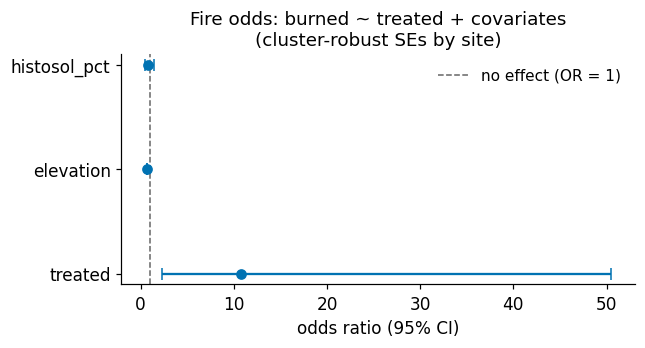

In [11]:
# Headline figure: odds ratio (95% CI) per term, saved to outputs/figures/modeling.
# treated < 1 (CI below the dashed line at OR=1) => restoration lowers fire odds.
tbl = or_table.drop(index="Intercept", errors="ignore")
ypos = np.arange(len(tbl))

fig, ax = plt.subplots(figsize=(6, 0.6 * len(tbl) + 1.5))
ax.errorbar(
    tbl["odds_ratio"],
    ypos,
    xerr=[tbl["odds_ratio"] - tbl["or_ci_low"], tbl["or_ci_high"] - tbl["odds_ratio"]],
    fmt="o",
    capsize=4,
    zorder=3,
)
ax.axvline(1.0, ls="--", color="0.4", lw=1, label="no effect (OR = 1)")
ax.set_yticks(ypos)
ax.set_yticklabels(tbl.index)
ax.set_xlabel("odds ratio (95% CI)")
ax.set_title("Fire odds: burned ~ treated + covariates\n(cluster-robust SEs by site)")
ax.legend()
fig.savefig(FIG_DIR / "odds_ratios.png", bbox_inches="tight")
print("saved", FIG_DIR / "odds_ratios.png")

### Next

- **Dry-year interaction.** Per-year climate is now built (`precip` / `tmax` /
  `tmin` under `processed/climate/annual/`) and `build_frame` joins it per
  `(x, y, year)`, so you can fit `burned ~ treated * precip + elevation +
  histosol_pct` to test whether restoration's effect is larger in dry years.
- Step up to `fit_mixed_logit` (site random intercept) to cross-check the SEs.
- Swap `product=` to a severity layer to re-run the whole thing for severity.